In [1]:
from copy import deepcopy

import numpy as np

import galsim

import ngmix
import metadetect

from roman_shear_sims.sim import make_sim
from roman_shear_sims.catalog import GalaxyCatalog, SimpleGalaxyCatalog
from roman_shear_sims.psf_makers import PSFMaker
from roman_shear_sims.constant import IMCOM_BLOCK_SIZE

from metacoadd.metadetect import MetaDetect
from metacoadd.moments.galsim_admom import GAdmomFitter

In [2]:
import matplotlib.pyplot as plt

In [3]:
seed = 4242
rng = np.random.RandomState(seed)

simu_type = "imcom"
simu_size = IMCOM_BLOCK_SIZE
bands = ["Y106"]#, "J129", "H158"]
gal_type = "gauss"
psf_type = simu_type
layout_kind = "grid"
chromatic=False
spacing = 12.
buff = 200
noise_sig = 1e-5
n_gal = None
gal_mag = 22
gal_hlr = 0.3
flux_range = [100, 1_00]

g1_in = 0.0
g2_in = 0.0

n_epochs = 1

exp_time=107

### Set Galaxy Catalog

In [4]:
# galaxy_catalog = GalaxyCatalog(
#     simu_size,
#     seed,
#     simu_type=simu_type,
#     flux_range=flux_range,
#     layout_kind=layout_kind,
#     exp_time=exp_time,
#     spacing=spacing,
#     buffer=buff,
#     n_gal=n_gal,
#     chromatic=chromatic,
# )
galaxy_catalog = SimpleGalaxyCatalog(
    simu_size,
    seed,
    simu_type=simu_type,
    gal_type=gal_type,
    mag=gal_mag,
    hlr=gal_hlr,
    layout_kind=layout_kind,
    exp_time=exp_time,
    spacing=spacing,
    buffer=buff,
    n_gal=n_gal,
    chromatic=chromatic,
)

### Set the PSF

In [5]:
psf_maker = PSFMaker(
    psf_type=psf_type,
    chromatic=chromatic,
)

### Run the simulation

In [6]:
simu_dict = make_sim(
    rng,
    galaxy_catalog,
    psf_maker,
    simu_type=simu_type,
    n_epochs=n_epochs,
    exp_time=exp_time,
    cell_size_pix=simu_size,
    bands=bands,
    g1=g1_in,
    g2=g2_in,
    chromatic=chromatic,
    simple_noise=True,
    noise_sigma=noise_sig,
    draw_method="fft",
    verbose=True,
)

Band loop:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch loop:   0%|          | 0/1 [00:00<?, ?it/s]

Obj loop:   0%|          | 0/64 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Gaussian profiles')

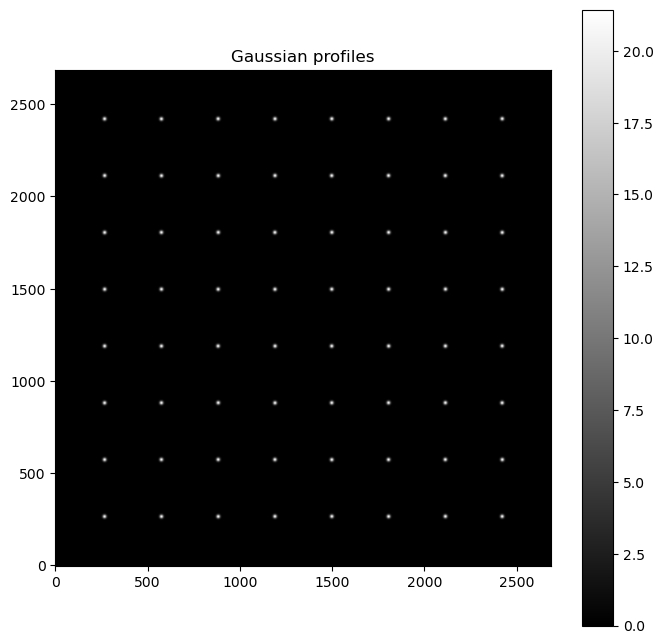

In [7]:
plt.figure(figsize=(8, 8))
plt.imshow(simu_dict["Y106"][0]["sci"]["shear_0.0_0.0"], origin="lower", cmap="gray")
plt.colorbar()
plt.title("Gaussian profiles")

### Run MetaDetect

In [8]:
# Make Observation
mbobs = ngmix.MultiBandObsList()
obslist = ngmix.ObsList()
for band in bands:
    for i in range(n_epochs):

        wcs = simu_dict[band][i]["wcs"]
        h = wcs.header
        g_jacob = wcs.jacobian(image_pos=galsim.PositionD(h["CRPIX1"], h["CRPIX2"]))

        img = simu_dict[band][i]["sci"][f"shear_{g1_in}_{g2_in}"]
        img_cen = (np.array(img.shape) - 1) / 2.0
        img_jacob = ngmix.Jacobian(
            row=img_cen[1],
            col=img_cen[0],
            wcs=g_jacob,
        )

        psf_img = simu_dict[band][i]["psf"]
        psf_cen = (np.array(psf_img.shape) - 1) / 2.0
        psf_jacob = ngmix.Jacobian(
            row=psf_cen[1],
            col=psf_cen[0],
            wcs=g_jacob,
        )

        psf_obs = ngmix.Observation(
            image=psf_img,
            jacobian=psf_jacob,
        )

        obs = ngmix.Observation(
            image=img,
            weight=simu_dict["Y106"][0]["weight"],
            noise=simu_dict[band][i]["noise"],
            psf=psf_obs,
            jacobian=img_jacob,
            ormask=np.zeros(img.shape, dtype=np.int32),
            bmask=np.zeros(img.shape, dtype=np.int32),
        )

        obslist.append(obs)
    mbobs.append(obslist)


In [9]:
gal_fitter = ngmix.gaussmom.GaussMom(fwhm=1.2)
gal_runner = ngmix.runners.Runner(fitter=gal_fitter)

psf_fitter = GAdmomFitter(guess_fwhm=0.6)
psf_runner = ngmix.runners.Runner(fitter=psf_fitter)


rng = np.random.RandomState(42)
mdet = MetaDetect(
    mbobs,
    rng=rng,
    psf_runner=psf_runner,
    gal_runner=gal_runner,
)

In [10]:
mdet._init_metacal()

In [11]:
mcal_mbobs = mdet.get_mcal("noshear")  # Just for timing comparison
mcal_mbobs = mdet.get_mcal("1p")

In [12]:
mcal_mbobs2 = ngmix.metacal.get_all_metacal(
    mbobs,
    psf="fitgauss",
    rng=np.random.RandomState(42),
    types=["noshear", "1p"],#, "1m", "2p", "2m"],
    use_noise_image=True,
)

Text(0.5, 1.0, 'Reconv PSF\nMetacoadd - ngmix.metacal')

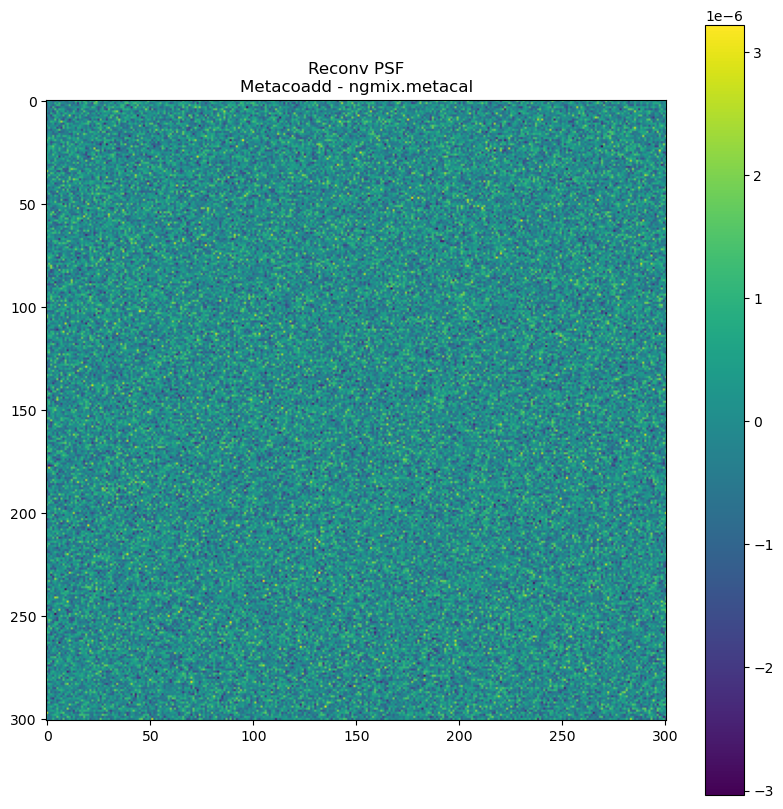

In [13]:
plt.figure(figsize=(10, 10))
plt.imshow(mcal_mbobs[0][0].psf.image-mcal_mbobs2["1p"][0][0].psf.image)
plt.colorbar()
plt.title("Reconv PSF\nMetacoadd - ngmix.metacal")

Text(0.5, 1.0, '1p image\nMetacoadd - ngmix.metacal')

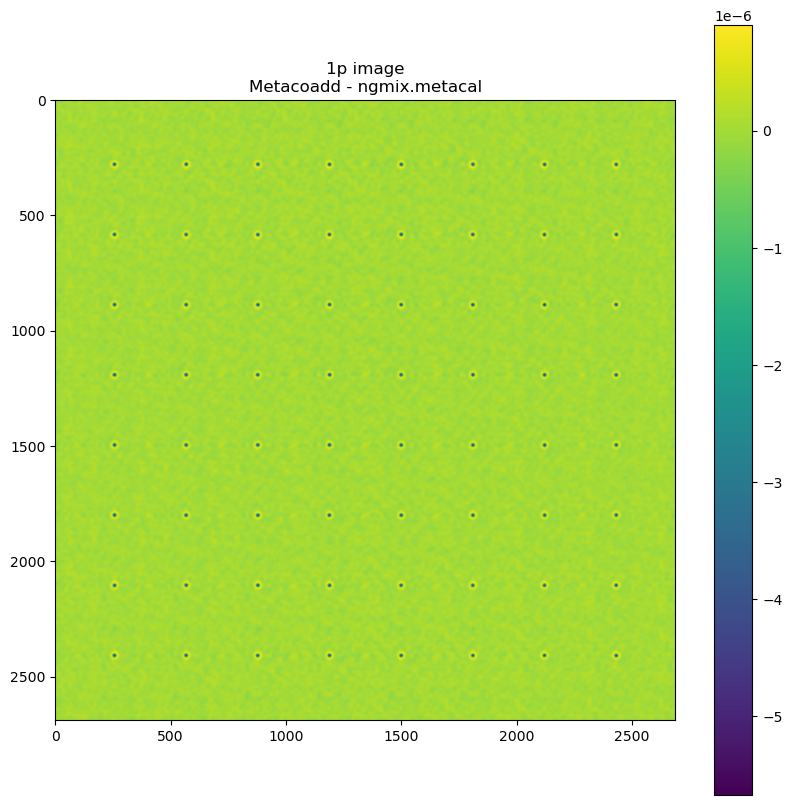

In [14]:
plt.figure(figsize=(10, 10))
plt.imshow(mcal_mbobs[0][0].image-mcal_mbobs2["1p"][0][0].image)
plt.colorbar()
plt.title("1p image\nMetacoadd - ngmix.metacal")

In [15]:
rng = np.random.RandomState(42)
mdet = MetaDetect(
    mbobs,
    rng=rng,
    psf_runner=psf_runner,
    gal_runner=gal_runner,
)
final_cat = mdet.go()

In [16]:
final_cat["1p"]["wmom_g1"]

array([0.01139315, 0.01164148, 0.01179924, 0.01005872, 0.00960797,
       0.01083234, 0.01011066, 0.01044326, 0.00918401, 0.00919373,
       0.00962586, 0.00968433, 0.00873952, 0.00983396, 0.0115108 ,
       0.01090556, 0.00897089, 0.00953423, 0.0109787 , 0.01020816,
       0.01016779, 0.01151591, 0.0102884 , 0.01127567, 0.0092223 ,
       0.00983336, 0.00842793, 0.0089483 , 0.01025824, 0.01021811,
       0.01197732, 0.01070556, 0.00960553, 0.00970771, 0.0101284 ,
       0.01125792, 0.01122639, 0.01076762, 0.00894426, 0.00871322,
       0.00939769, 0.00824513, 0.00964616, 0.01056526, 0.01041142,
       0.01004603, 0.0104681 , 0.00948252, 0.00999608, 0.00974096,
       0.00989363, 0.01039071, 0.01083519, 0.00856423, 0.00970904,
       0.01174542, 0.00886671, 0.01121728, 0.00937604, 0.01100973,
       0.00889111, 0.00997763, 0.01005909, 0.00830156])

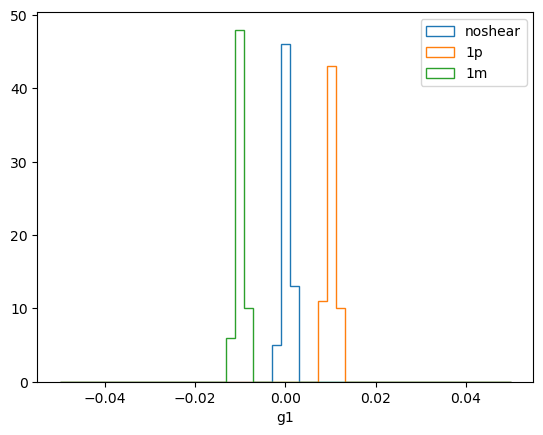

In [17]:
bins = np.linspace(-0.05, 0.05, 50)
plt.hist(final_cat["noshear"]["wmom_g1"], bins, histtype="step", label="noshear")
plt.hist(final_cat["1p"]["wmom_g1"], bins, histtype="step", label="1p")
plt.hist(final_cat["1m"]["wmom_g1"], bins, histtype="step", label="1m")
plt.xlabel("g1")
plt.legend()

### Run "offcial" MetaDetect

In [18]:
# Size of the taget Gaussian PSF in IMCOM
PSF_FWHM = {
    "Y106": 0.22,
    "J129": 0.231,
    "H158": 0.242,
    "F184": 0.253,
    "K213": 0.264,
}
# Size of the image used to draw the PSF
PSF_IMG_SIZE = 151

# Size of one IMCOM block
IMG_SIZE = 2688
# Boundary used to avoid edge effects
# Objects for which the centre is within this distance from the edge will be
# masked out.
BOUND_SIZE = 100

METADETECT_CONFIG = {
    # Shape measurement method
    # wmom: weighted moments
    "model": "wmom",

    # Size of the weight function for the moments
    'weight': {
        'fwhm': 1.2,  # arcsec
    },

    # Metacal settings
    'metacal': {
        'psf': 'fitgauss',
        # Kind of shear applied to the image
        'types': ['noshear', '1p', '1m', '2p', '2m'],
        'use_noise_image': True,
        'fixnoise': True,
    },

    'sx': {
        # in sky sigma
        # DETECT_THRESH
        'detect_thresh': 1500,

        # Minimum contrast parameter for deblending
        # DEBLEND_MINCONT
        'deblend_cont': 0.005,

        # minimum number of pixels above threshold
        # DETECT_MINAREA: 6
        'minarea': 5,

        'filter_type': 'conv',

        # 7x7 convolution mask of a gaussian PSF with FWHM = 3.0 pixels.
        'filter_kernel': [
            [0.004963, 0.021388, 0.051328, 0.068707, 0.051328, 0.021388, 0.004963],  # noqa
            [0.021388, 0.092163, 0.221178, 0.296069, 0.221178, 0.092163, 0.021388],  # noqa
            [0.051328, 0.221178, 0.530797, 0.710525, 0.530797, 0.221178, 0.051328],  # noqa
            [0.068707, 0.296069, 0.710525, 0.951108, 0.710525, 0.296069, 0.068707],  # noqa
            [0.051328, 0.221178, 0.530797, 0.710525, 0.530797, 0.221178, 0.051328],  # noqa
            [0.021388, 0.092163, 0.221178, 0.296069, 0.221178, 0.092163, 0.021388],  # noqa
            [0.004963, 0.021388, 0.051328, 0.068707, 0.051328, 0.021388, 0.004963],  # noqa
        ]
    },

    # This is for the cutout at each detection
    'meds': {
        'min_box_size': 31,
        'max_box_size': 31,

        'box_type': 'iso_radius',

        'rad_min': 4,
        'rad_fac': 2,
        'box_padding': 2,
    },

    # check for an edge hit
    'bmask_flags': 2**30,

    'nodet_flags': 2**0,
}

In [19]:
res = metadetect.do_metadetect(
    deepcopy(METADETECT_CONFIG),
    mbobs=mbobs,
    rng=np.random.RandomState(42),
)

In [20]:
res["1p"]["wmom_g"][:, 0]

array([0.01139315, 0.01164147, 0.01179924, 0.01005872, 0.00960799,
       0.01083236, 0.01011065, 0.01044326, 0.00918403, 0.00919375,
       0.0096259 , 0.00968431, 0.00873955, 0.00983397, 0.0115108 ,
       0.01090558, 0.0089709 , 0.00953423, 0.01097871, 0.01020817,
       0.01016778, 0.01151593, 0.01028844, 0.01127565, 0.00922231,
       0.00983338, 0.00842792, 0.00894828, 0.01025824, 0.01021811,
       0.01197728, 0.01070557, 0.00960554, 0.00970771, 0.01012841,
       0.0112579 , 0.01122638, 0.01076761, 0.00894421, 0.00871321,
       0.0093977 , 0.00824526, 0.00964616, 0.01056525, 0.01041139,
       0.01004607, 0.01046814, 0.00948242, 0.00999609, 0.00974097,
       0.00989364, 0.01039071, 0.01083517, 0.00856417, 0.00970896,
       0.0117455 , 0.00886666, 0.01121725, 0.00937605, 0.01100969,
       0.00889112, 0.00997763, 0.0100591 , 0.00830167])

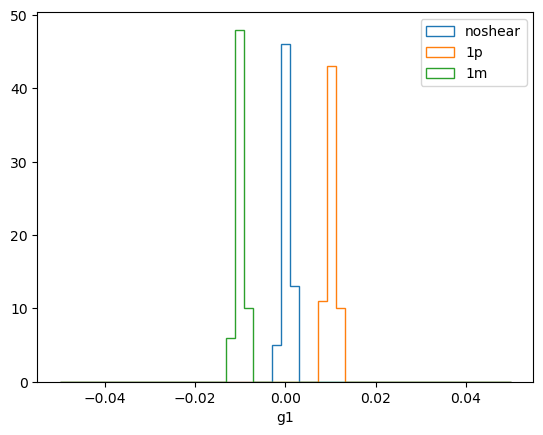

In [21]:
bins = np.linspace(-0.05, 0.05, 50)
plt.hist(res["noshear"]["wmom_g"][:, 0], bins, histtype="step", label="noshear")
plt.hist(res["1p"]["wmom_g"][:, 0], bins, histtype="step", label="1p")
plt.hist(res["1m"]["wmom_g"][:, 0], bins, histtype="step", label="1m")
plt.xlabel("g1")
plt.legend()

### Compare output

In [22]:
print("noshear:", len(final_cat["noshear"]), len(res["noshear"]))
print("1p:", len(final_cat["1p"]), len(res["1p"]))
print("1m:", len(final_cat["1m"]), len(res["1m"]))
print("2p:", len(final_cat["2p"]), len(res["2p"]))
print("2m:", len(final_cat["2m"]), len(res["2m"]))

noshear: 64 64
1p: 64 64
1m: 64 64
2p: 64 64
2m: 64 64


Text(0.5, 1.0, 'g1 for noshear')

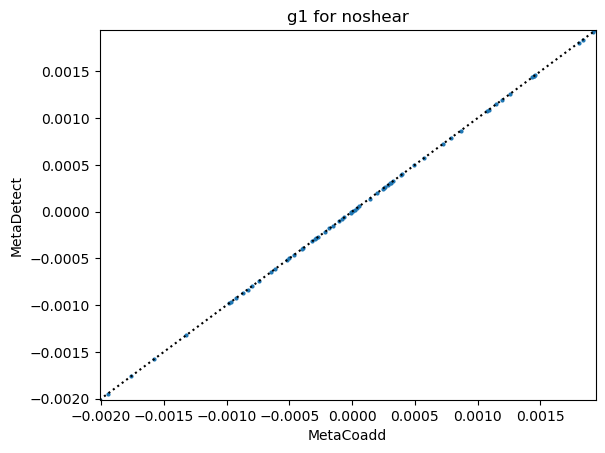

In [23]:
vmin = np.min([final_cat["noshear"]["wmom_g1"], res["noshear"]["wmom_g"][:, 0]])
vmax = np.max([final_cat["noshear"]["wmom_g1"], res["noshear"]["wmom_g"][:, 0]])
plt.plot(final_cat["noshear"]["wmom_g1"], res["noshear"]["wmom_g"][:, 0], "o", markersize=2,)
plt.axline((0., 0.), slope=1, color="k", linestyle=":")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")
plt.title("g1 for noshear")

Text(0.5, 1.0, 'g1 for noshear')

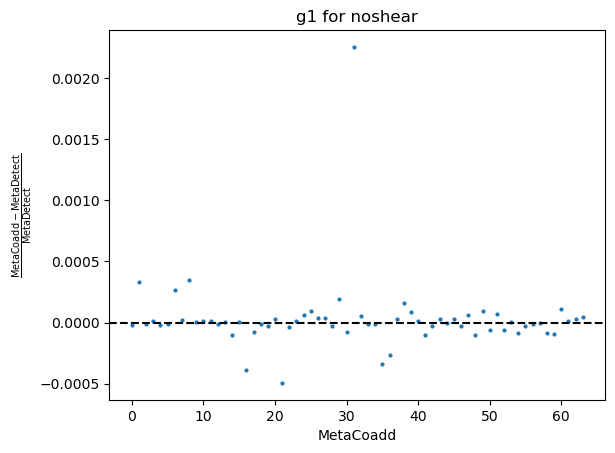

In [24]:
plt.plot((final_cat["noshear"]["wmom_g1"]-res["noshear"]["wmom_g"][:, 0])/res["noshear"]["wmom_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for noshear")

Text(0.5, 1.0, 'g1 for 1p')

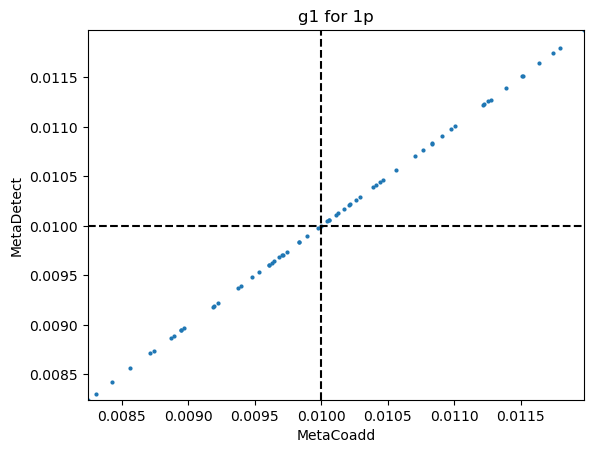

In [25]:
vmin = np.min([final_cat["1p"]["wmom_g1"], res["1p"]["wmom_g"][:, 0]])
vmax = np.max([final_cat["1p"]["wmom_g1"], res["1p"]["wmom_g"][:, 0]])
plt.plot(final_cat["1p"]["wmom_g1"], res["1p"]["wmom_g"][:, 0], "o", markersize=2, label="noshear")
plt.axvline(0.01, color="k", linestyle="--")
plt.axhline(0.01, color="k", linestyle="--")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")
plt.title("g1 for 1p")

Text(0.5, 1.0, 'g1 for 1p')

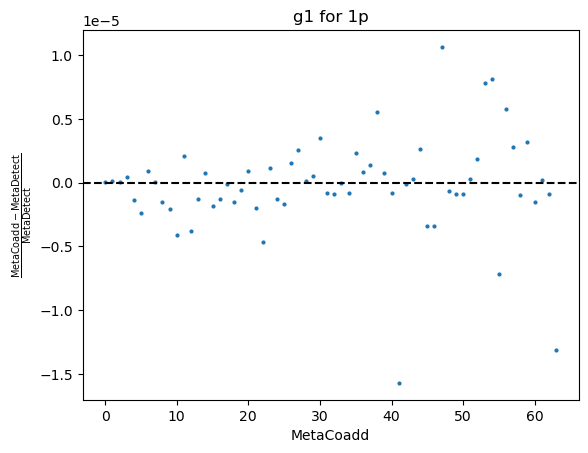

In [26]:
plt.plot((final_cat["1p"]["wmom_g1"]-res["1p"]["wmom_g"][:, 0])/res["1p"]["wmom_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for 1p")

Text(0, 0.5, 'MetaDetect')

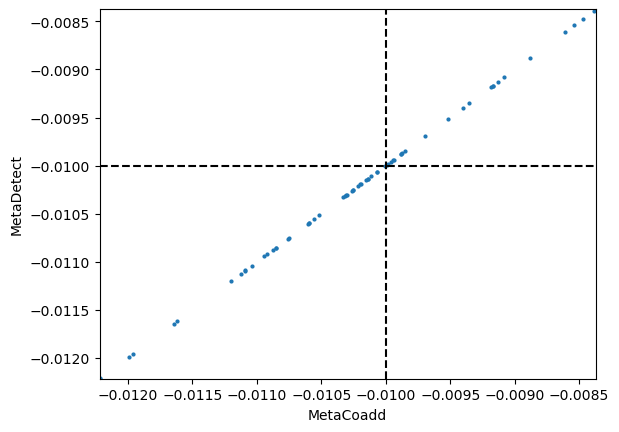

In [27]:
vmin = np.min([final_cat["1m"]["wmom_g1"], res["1m"]["wmom_g"][:, 0]])
vmax = np.max([final_cat["1m"]["wmom_g1"], res["1m"]["wmom_g"][:, 0]])
plt.plot(final_cat["1m"]["wmom_g1"], res["1m"]["wmom_g"][:, 0], "o", markersize=2, label="noshear")
plt.axvline(-0.01, color="k", linestyle="--")
plt.axhline(-0.01, color="k", linestyle="--")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")

Text(0.5, 1.0, 'g1 for 1m')

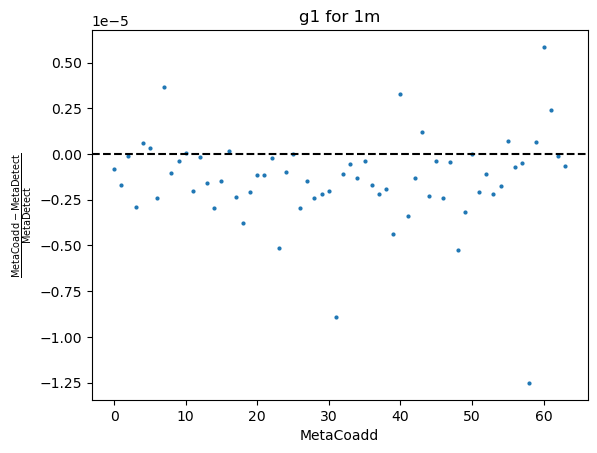

In [28]:
plt.plot((final_cat["1m"]["wmom_g1"]-res["1m"]["wmom_g"][:, 0])/res["1m"]["wmom_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for 1m")

Text(0.5, 1.0, 'g1 for 2m')

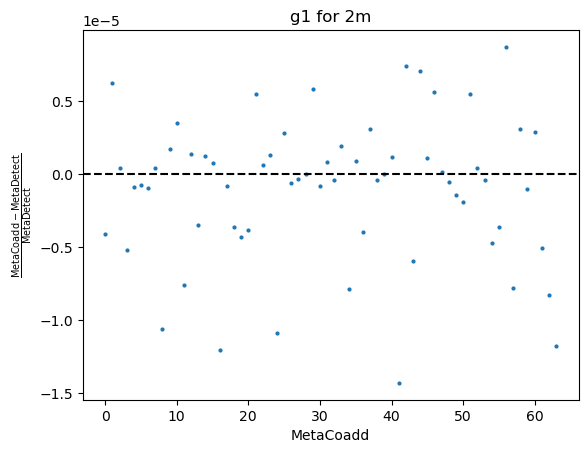

In [29]:
plt.plot((final_cat["2m"]["wmom_g2"]-res["2m"]["wmom_g"][:, 1])/res["2m"]["wmom_g"][:, 1], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for 2m")

Text(0, 0.5, 'MetaDetect')

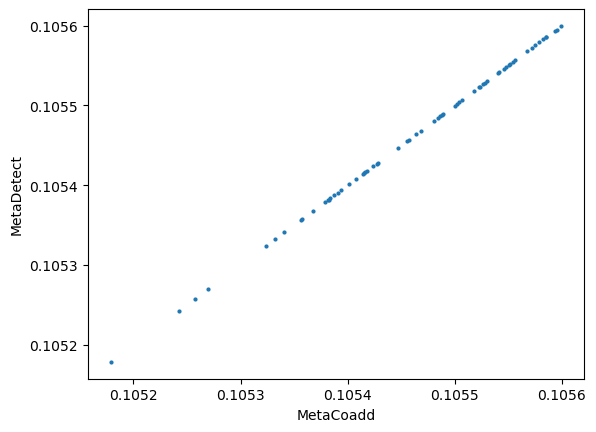

In [30]:
plt.plot(final_cat["1m"]["wmom_T"], res["1m"]["wmom_T"], "o", markersize=2, label="noshear")
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")

Text(0.5, 1.0, 'T for noshear')

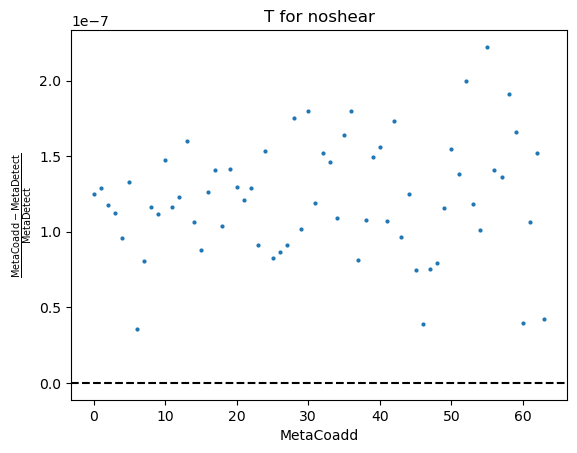

In [31]:
plt.plot((final_cat["noshear"]["wmom_T"]-res["noshear"]["wmom_T"])/res["noshear"]["wmom_T"], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("T for noshear")

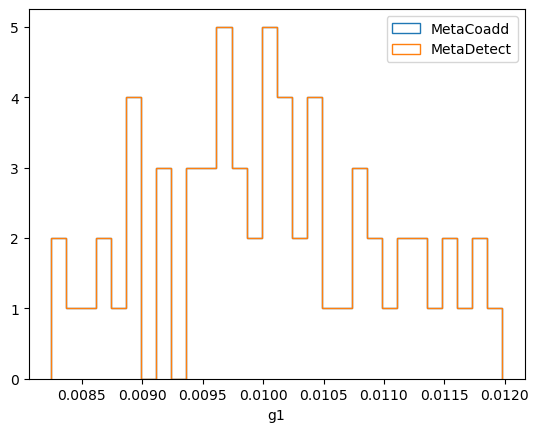

In [32]:
key = "1p"
good_mc = (final_cat[key]["wmom_flags"] == 0) & (final_cat[key]["wmom_s2n"] > 10)
good_md = (res[key]["wmom_flags"] == 0) & (res[key]["wmom_s2n"] > 10)
plt.hist(final_cat[key]["wmom_g1"][good_mc], 30, histtype="step", label="MetaCoadd")
plt.hist(res[key]["wmom_g"][good_md, 0], 30, histtype="step", label="MetaDetect")
plt.xlabel("g1")
plt.legend()

In [33]:
final_cat[key]["wmom_g1"]

array([0.01139315, 0.01164148, 0.01179924, 0.01005872, 0.00960797,
       0.01083234, 0.01011066, 0.01044326, 0.00918401, 0.00919373,
       0.00962586, 0.00968433, 0.00873952, 0.00983396, 0.0115108 ,
       0.01090556, 0.00897089, 0.00953423, 0.0109787 , 0.01020816,
       0.01016779, 0.01151591, 0.0102884 , 0.01127567, 0.0092223 ,
       0.00983336, 0.00842793, 0.0089483 , 0.01025824, 0.01021811,
       0.01197732, 0.01070556, 0.00960553, 0.00970771, 0.0101284 ,
       0.01125792, 0.01122639, 0.01076762, 0.00894426, 0.00871322,
       0.00939769, 0.00824513, 0.00964616, 0.01056526, 0.01041142,
       0.01004603, 0.0104681 , 0.00948252, 0.00999608, 0.00974096,
       0.00989363, 0.01039071, 0.01083519, 0.00856423, 0.00970904,
       0.01174542, 0.00886671, 0.01121728, 0.00937604, 0.01100973,
       0.00889111, 0.00997763, 0.01005909, 0.00830156])

In [34]:
res[key]["wmom_g"][:, 0]

array([0.01139315, 0.01164147, 0.01179924, 0.01005872, 0.00960799,
       0.01083236, 0.01011065, 0.01044326, 0.00918403, 0.00919375,
       0.0096259 , 0.00968431, 0.00873955, 0.00983397, 0.0115108 ,
       0.01090558, 0.0089709 , 0.00953423, 0.01097871, 0.01020817,
       0.01016778, 0.01151593, 0.01028844, 0.01127565, 0.00922231,
       0.00983338, 0.00842792, 0.00894828, 0.01025824, 0.01021811,
       0.01197728, 0.01070557, 0.00960554, 0.00970771, 0.01012841,
       0.0112579 , 0.01122638, 0.01076761, 0.00894421, 0.00871321,
       0.0093977 , 0.00824526, 0.00964616, 0.01056525, 0.01041139,
       0.01004607, 0.01046814, 0.00948242, 0.00999609, 0.00974097,
       0.00989364, 0.01039071, 0.01083517, 0.00856417, 0.00970896,
       0.0117455 , 0.00886666, 0.01121725, 0.00937605, 0.01100969,
       0.00889112, 0.00997763, 0.0100591 , 0.00830167])

In [35]:
res["noshear"]["wmom_T"]

array([0.10551568, 0.10545392, 0.10549092, 0.10556407, 0.10524438,
       0.10539989, 0.10522277, 0.105391  , 0.10553227, 0.10538744,
       0.10526428, 0.10543161, 0.10528021, 0.10533103, 0.10546503,
       0.10535884, 0.10559832, 0.10530103, 0.10550839, 0.10553935,
       0.10542387, 0.10552787, 0.10556884, 0.10537777, 0.10531787,
       0.10527705, 0.10548826, 0.10545823, 0.10536431, 0.1053496 ,
       0.10535881, 0.10559489, 0.10541436, 0.1054482 , 0.10537226,
       0.10536196, 0.10544715, 0.10552136, 0.10559408, 0.10530022,
       0.10539408, 0.1053825 , 0.10539705, 0.10539641, 0.10559554,
       0.10544656, 0.10523541, 0.10551824, 0.1054637 , 0.10555261,
       0.10557859, 0.10539783, 0.10543752, 0.10543296, 0.10543931,
       0.10539211, 0.10537669, 0.10543655, 0.10550616, 0.10533182,
       0.10548203, 0.10551412, 0.10539106, 0.10545401])

In [36]:
final_cat["noshear"]["wmom_T"]

array([0.10551569, 0.10545394, 0.10549094, 0.10556408, 0.10524439,
       0.10539991, 0.10522277, 0.10539101, 0.10553229, 0.10538745,
       0.10526429, 0.10543162, 0.10528022, 0.10533105, 0.10546504,
       0.10535885, 0.10559833, 0.10530105, 0.1055084 , 0.10553936,
       0.10542388, 0.10552788, 0.10556885, 0.10537778, 0.10531789,
       0.10527706, 0.10548827, 0.10545824, 0.10536433, 0.10534961,
       0.10535883, 0.1055949 , 0.10541437, 0.10544821, 0.10537227,
       0.10536198, 0.10544717, 0.10552137, 0.10559409, 0.10530023,
       0.1053941 , 0.10538251, 0.10539706, 0.10539642, 0.10559555,
       0.10544656, 0.10523541, 0.10551825, 0.10546371, 0.10555262,
       0.10557861, 0.10539784, 0.10543754, 0.10543297, 0.10543932,
       0.10539214, 0.10537671, 0.10543656, 0.10550618, 0.10533184,
       0.10548204, 0.10551413, 0.10539107, 0.10545401])